In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# Dataset

In [2]:
(xtr,ytr), (xte,yte) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
display(xtr.shape,ytr.shape)


(60000, 28, 28)

(60000,)

Text(0.5, 1.0, 'lable is : 3')

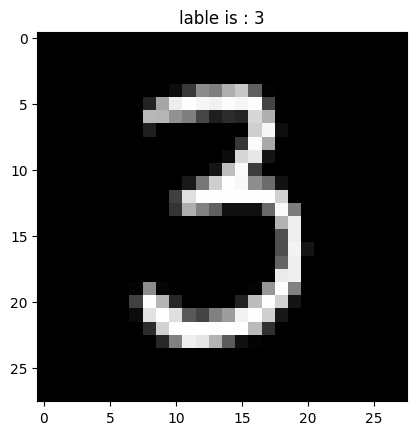

In [ ]:
from matplotlib import pyplot as plt
img_in = 50
plt.imshow(xtr[img_in],cmap="gray")
plt.title(f"lable is : {ytr[img_in]}")

# ANNs

In [ ]:
ann = tf.keras.Sequential([
    layers.Input(shape=(28,28)),
    layers.Rescaling(1./255),
    layers.Flatten(),
    layers.Dense(400,activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(200,activation="relu"),
    layers.Dropout(0.25),
    layers.Dense(100,activation="relu"),
    layers.Dense(10,activation="softmax")
])

ann.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"
            ])


In [ ]:
ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 415,310 (1.58 MB)

 Trainable params: 415,310 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann.fit(xtr,ytr,epochs=10,validation_data=(xte,yte))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8646 - loss: 0.4364 - val_accuracy: 0.9594 - val_loss: 0.1301
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9621 - loss: 0.1271 - val_accuracy: 0.9676 - val_loss: 0.1019
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9723 - loss: 0.0941 - val_accuracy: 0.9741 - val_loss: 0.0862
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9755 - loss: 0.0784 - val_accuracy: 0.9737 - val_loss: 0.0928
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9791 - loss: 0.0672 - val_accuracy: 0.9793 - val_loss: 0.0706
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9823 - loss: 0.0558 - val_accuracy: 0.9773 - val_loss: 0.0840
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9829 - loss: 0.0543 - val_accuracy: 0.9810 - val_loss: 0.0686
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9853 - loss: 0.0475 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
confidence vector: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]
predicted label: 5


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

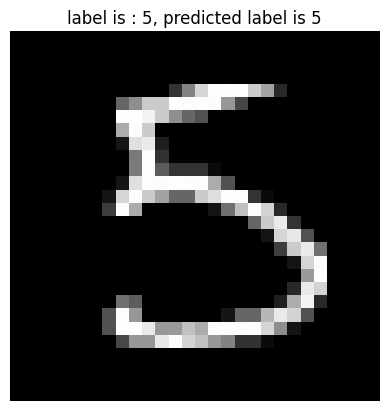

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

index = 15
sample = xte[index]

# batch dimension add
sample_batch = sample.reshape(1,28,28)   # (1, 28, 28)

y_pred = np.round(ann.predict(sample_batch))

print("confidence vector:", y_pred)
print("predicted label:", ylb := np.argmax(y_pred))

plt.imshow(sample, cmap="gray")
plt.title(f"label is : {yte[index]}, predicted label is {ylb}")
plt.axis("off")

# **ANN performace**
## text val_accuracy: *98.26 %* - val_loss: *6.97 %*


---



---


# Time for CNN


In [3]:
cnn = tf.keras.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Rescaling(1./255),
    layers.Conv2D(65,(3,3),activation="relu"),
    # layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation="relu"),
    # layers.MaxPooling2D((2,2)),
    layers.Conv2D(32,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(16,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(100,activation="relu"),
    layers.Dense(10,activation="softmax")
])

cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
            )

In [4]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 65)     │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        75,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 22, 32)     │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 9, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,888 (562.06 KB)

 Trainable params: 143,888 (562.06 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
tf.debugging.set_log_device_placement(True) # GPU ko bulalo, bahi cpu (8 min) per epoch le ra hai

In [6]:
cnn.fit(xtr, ytr, epochs=10, validation_data=(xte, yte))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8941 - loss: 0.3335 - val_accuracy: 0.9835 - val_loss: 0.0502
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9842 - loss: 0.0520 - val_accuracy: 0.9845 - val_loss: 0.0443
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9881 - loss: 0.0392 - val_accuracy: 0.9891 - val_loss: 0.0359
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9900 - loss: 0.0312 - val_accuracy: 0.9901 - val_loss: 0.0292
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9920 - loss: 0.0250 - val_accuracy: 0.9920 - val_loss: 0.0277
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9940 - loss: 0.0194 - val_accuracy: 0.9906 - val_loss: 0.0274
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9945 - loss: 0.0167 - val_accuracy: 0.9918 - val_loss: 0.0290
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9957 - loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step
confidence vector: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]
predicted label: 9


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

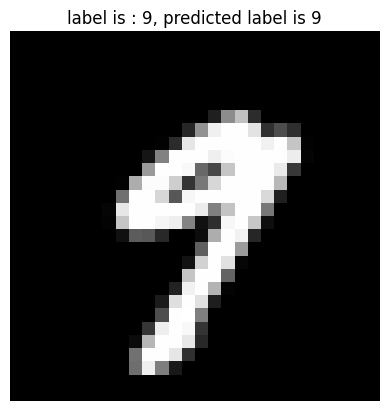

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

index = 20
sample = xte[index]

# batch dimension add
sample_batch = sample.reshape(1,28,28)   # (1, 28, 28)

y_pred = np.round(cnn.predict(sample_batch))

print("confidence vector:", y_pred)
print("predicted label:", ylb := np.argmax(y_pred))

plt.imshow(sample, cmap="gray")
plt.title(f"label is : {yte[index]}, predicted label is {ylb}")
plt.axis("off")

# Results of both **model**

## ANN is 98.3 %



## CNN is 99.0 %

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


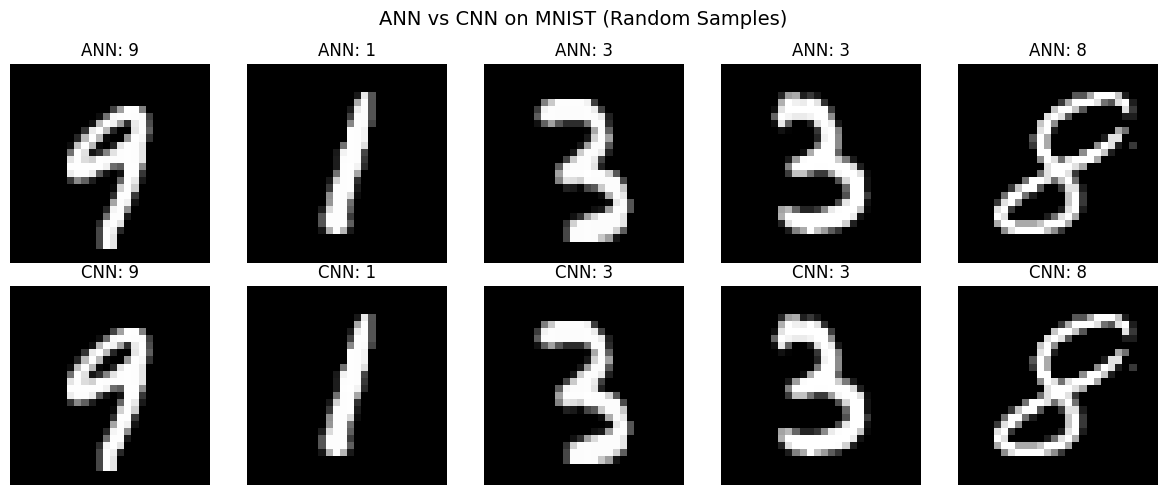

In [ ]:
idx = np.random.choice(len(xte), 5, replace=False)

x_ann = xte[idx]     # ANN
x_cnn = xte[idx]     # CNN bhi SAME input

ann_preds = np.argmax(ann.predict(x_ann), axis=1)
cnn_preds = np.argmax(cnn.predict(x_cnn), axis=1)

plt.figure(figsize=(12,5))
for i in range(5):
    # -------- ANN row --------
    plt.subplot(2, 5, i+1)
    plt.imshow(xte[idx[i]], cmap='gray')
    plt.title(f"ANN: {ann_preds[i]}")
    plt.axis('off')

    # -------- CNN row --------
    plt.subplot(2, 5, i+6)
    plt.imshow(xte[idx[i]], cmap='gray')
    plt.title(f"CNN: {cnn_preds[i]}")
    plt.axis('off')

plt.suptitle("ANN vs CNN on MNIST (Random Samples)", fontsize=14)
plt.tight_layout()
plt.show()

# Parameters kam hai, phir bhi CNN slow kyu?
### CNN slow hota hai kyunki computation heavy hota hai, parameters se nahi balki operations se time lagta hai.

Force GPU karna pade ga
```
with tf.device('/GPU:0'):
    cnn.fit(...)
```
CNN training me:

* convolution gradient





* kernel update

* feature map gradient

ANN me:

* simple matrix gradient


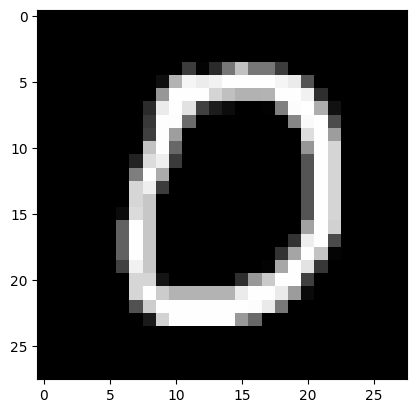

In [41]:
import matplotlib.pyplot as plt
index = 10
plt.imshow(xte[index],cmap="gray")

# How Cnn(convolutional and pooling work) layer working ? 🤔
### yahan layer do baar repeat ho rahi hai, uss jagah MaxPooling use hua hai

In [42]:
dummy_img = xte[index].reshape(1,28,28,1).astype("float32")
feature_maps = visualization_model.predict(dummy_img)

print(f"Total layers extracted: {len(feature_maps)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Total layers extracted: 6


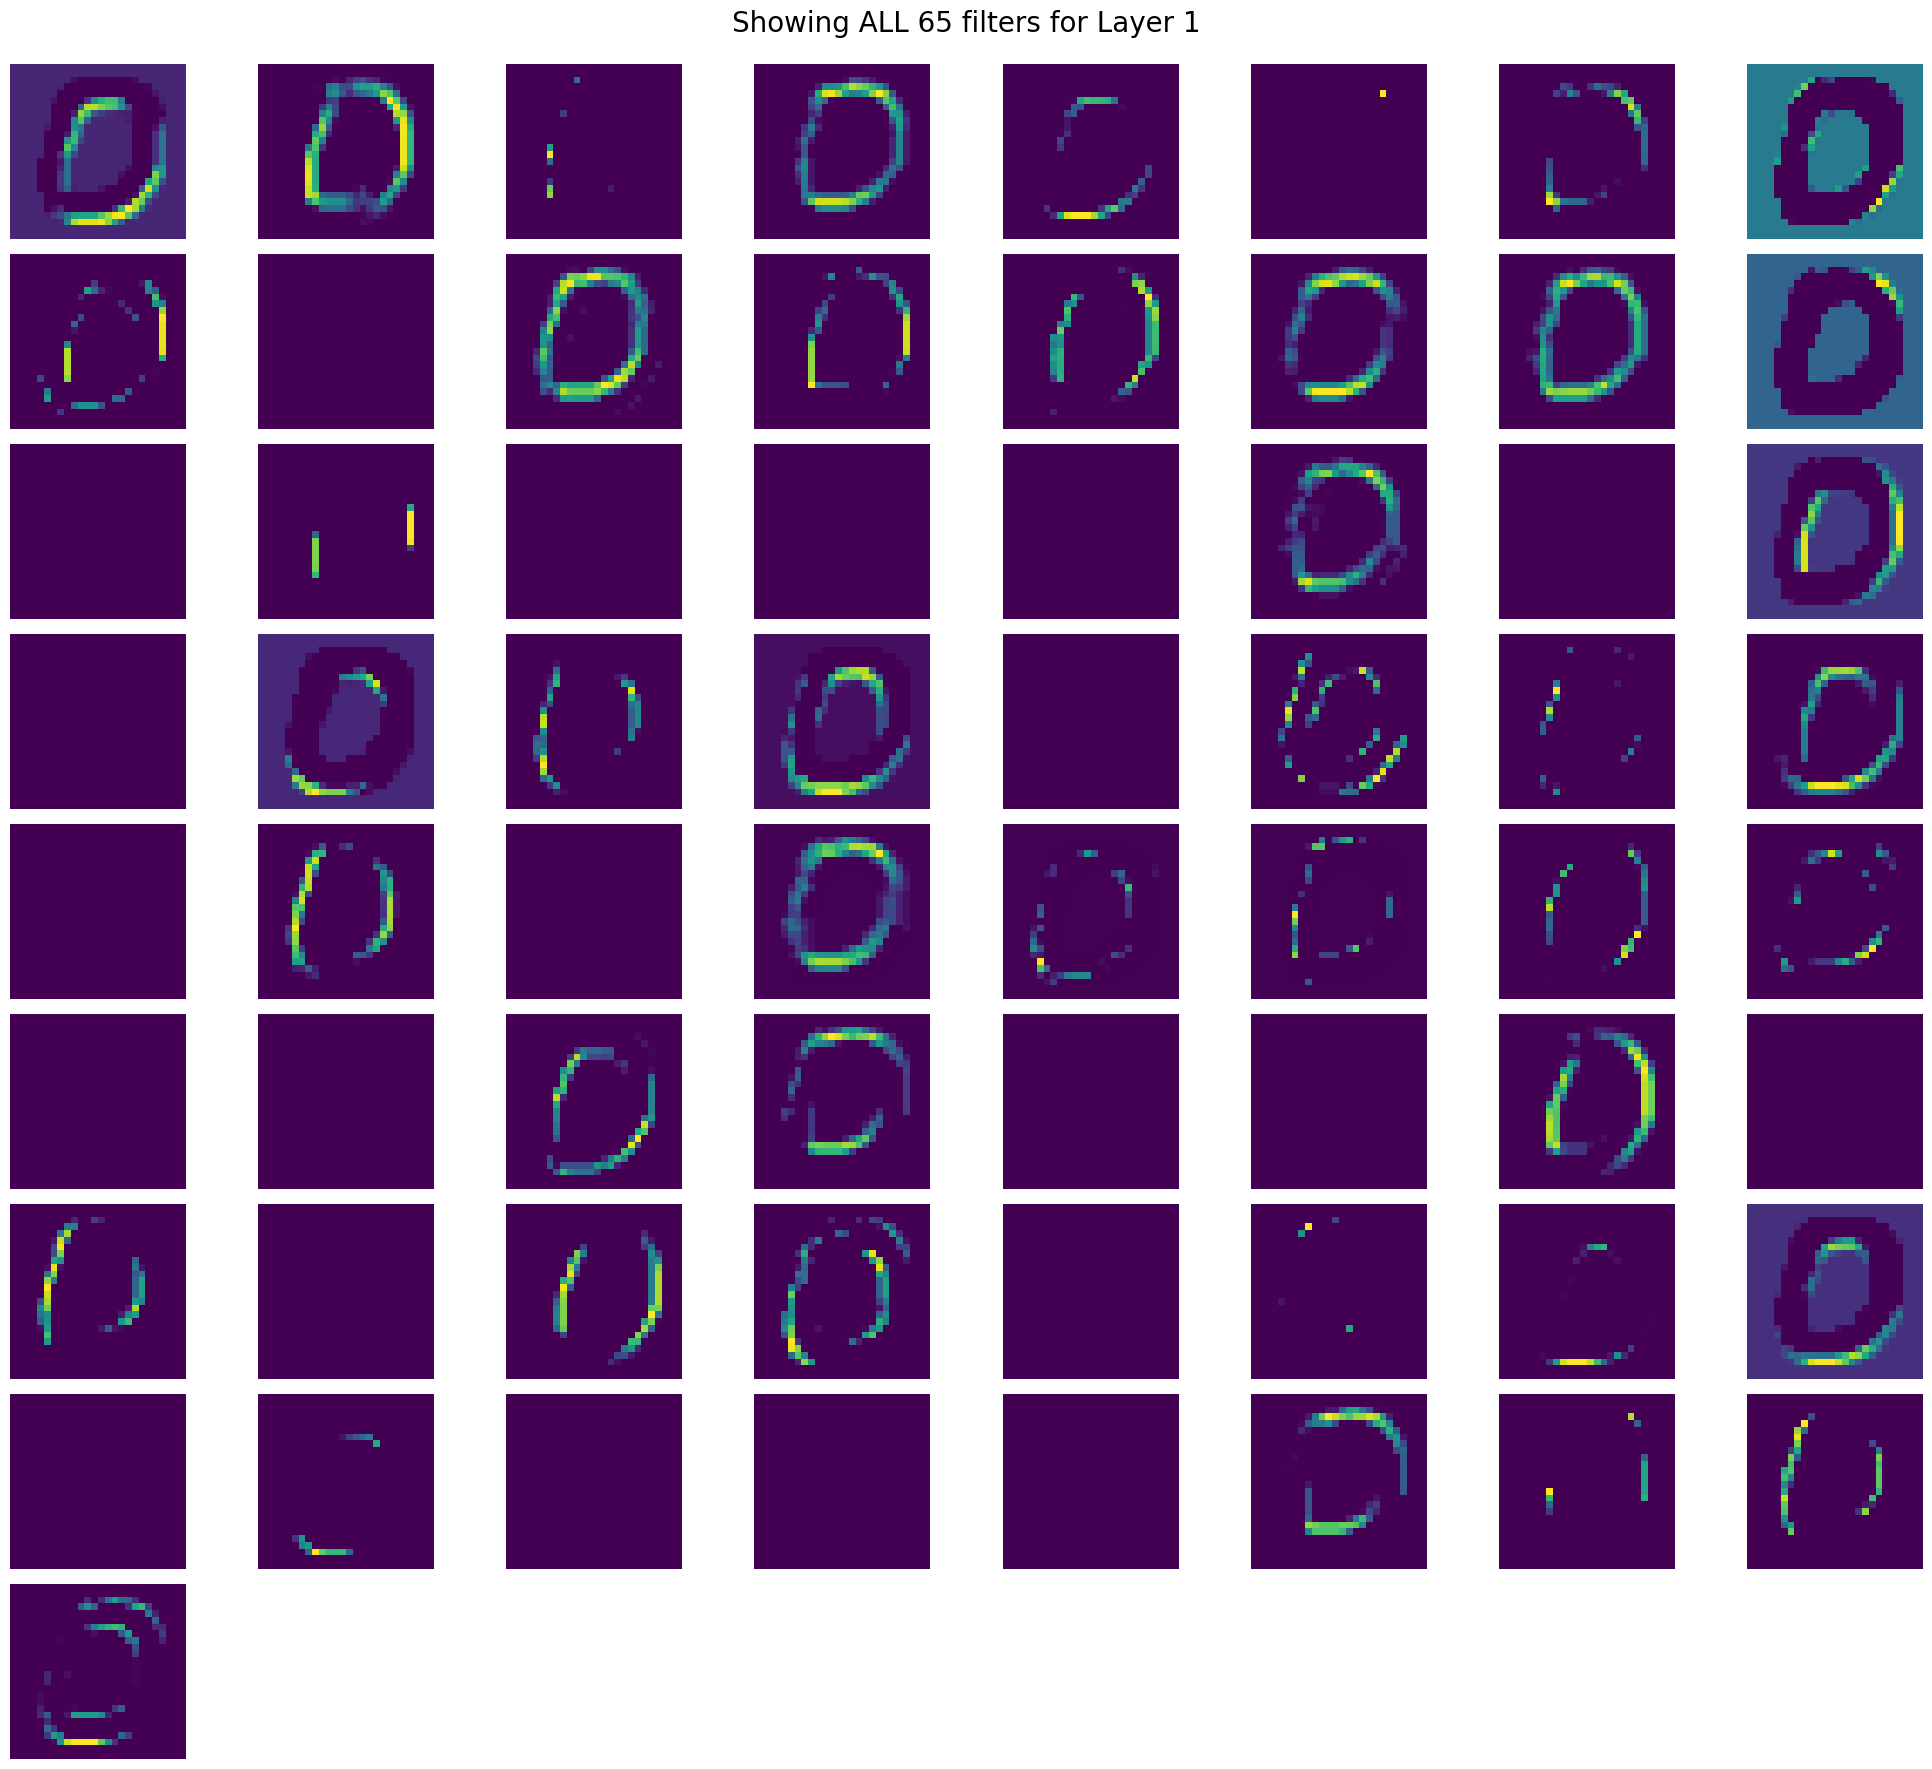

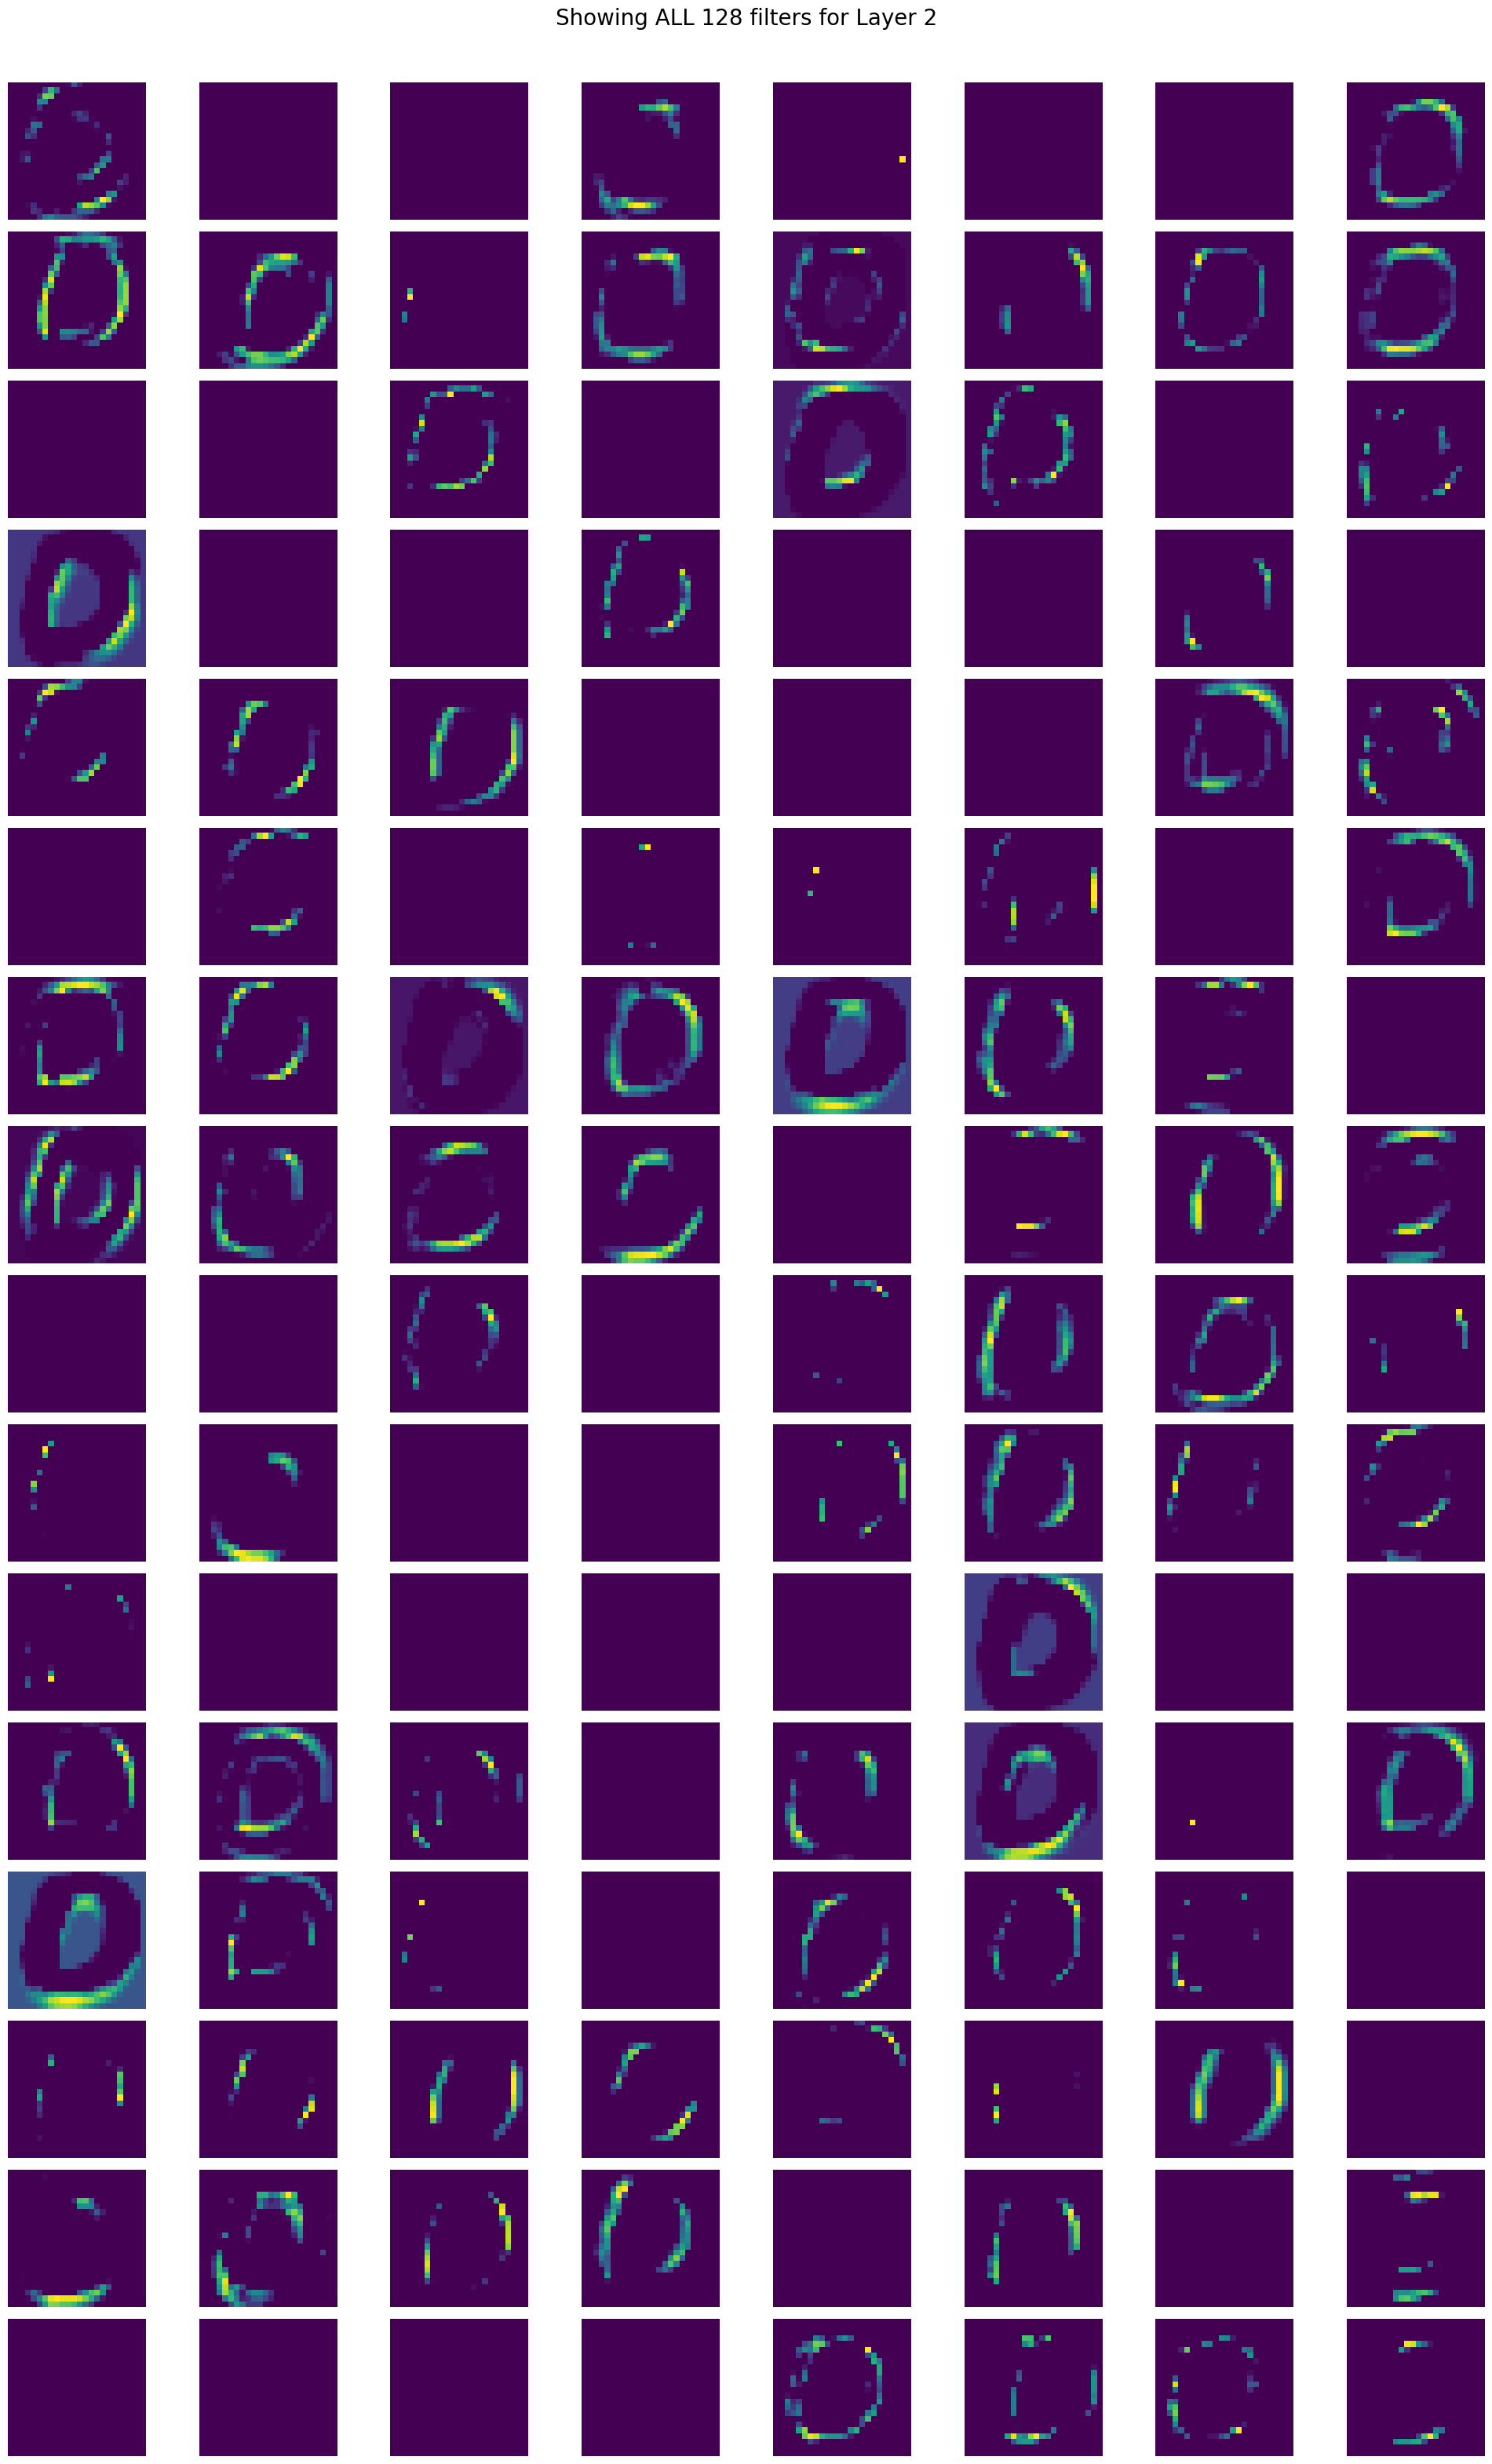

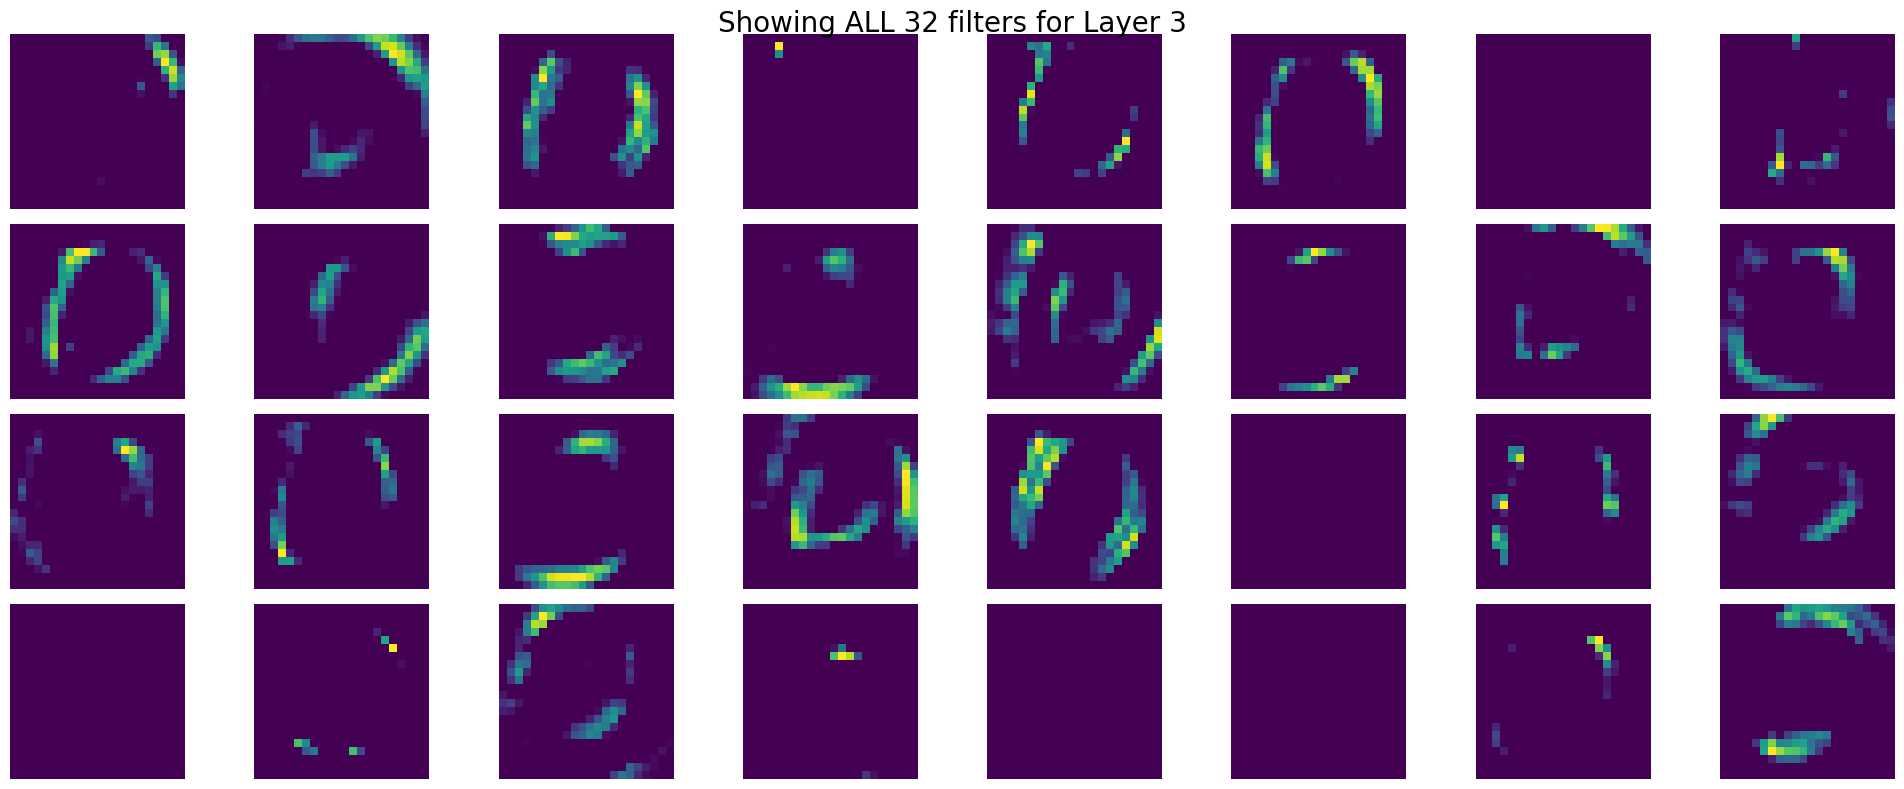

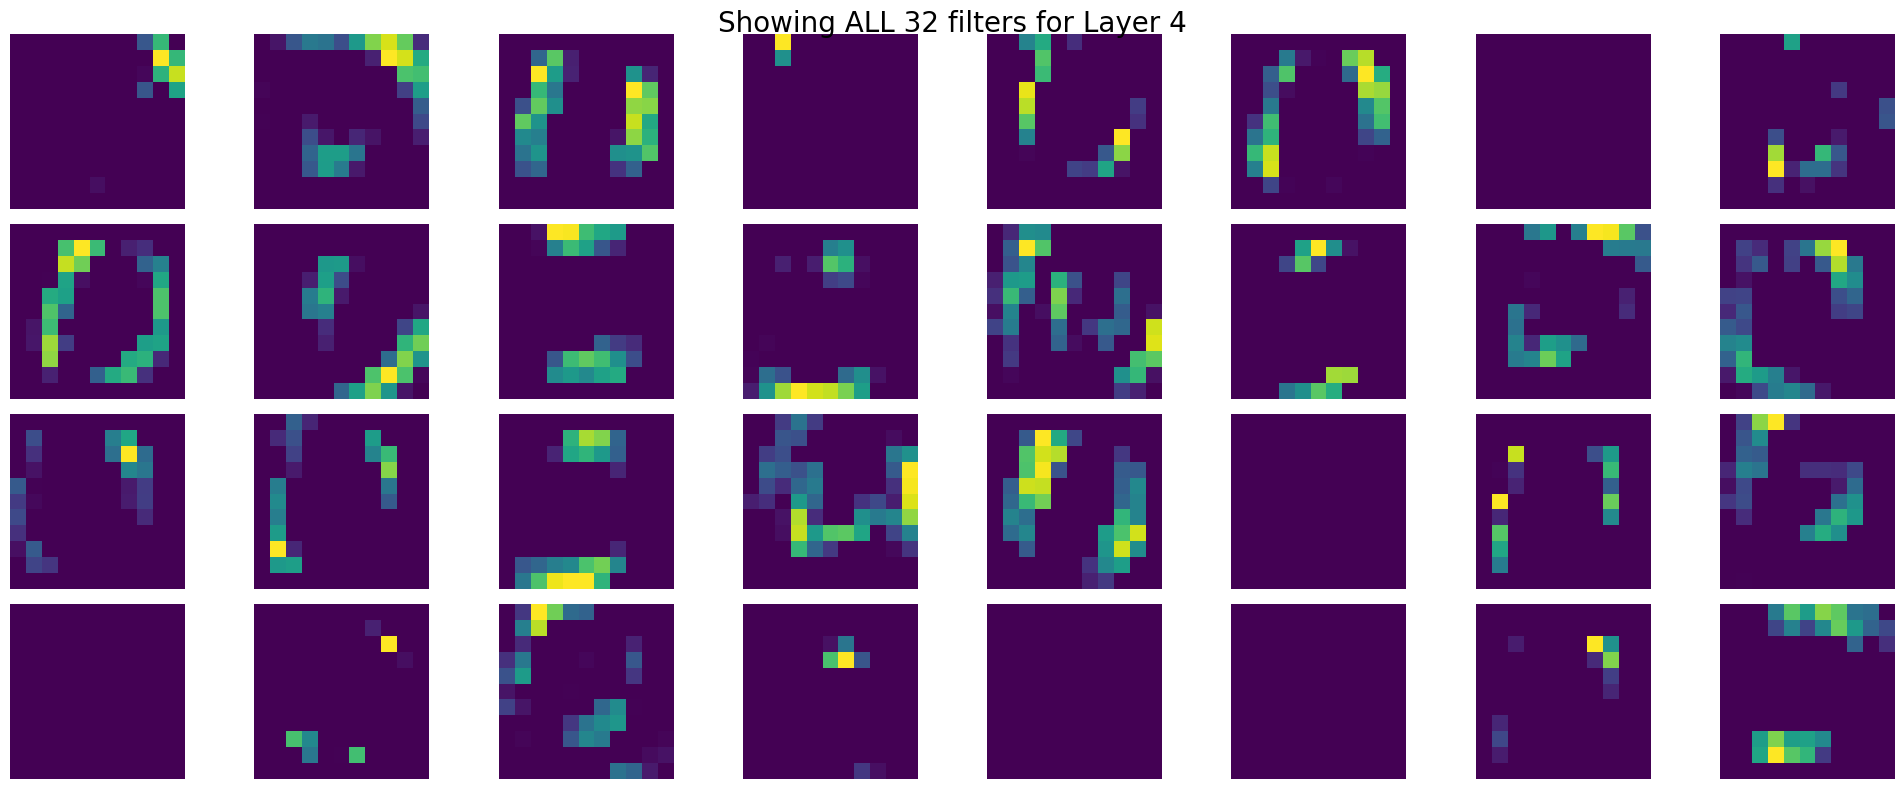

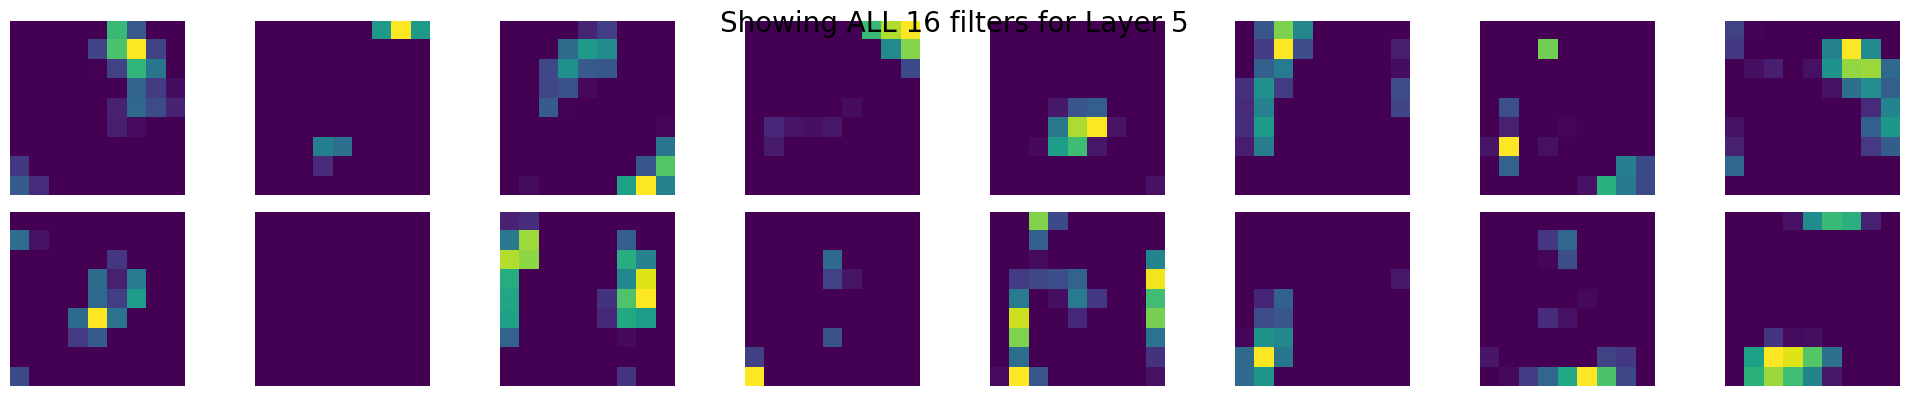

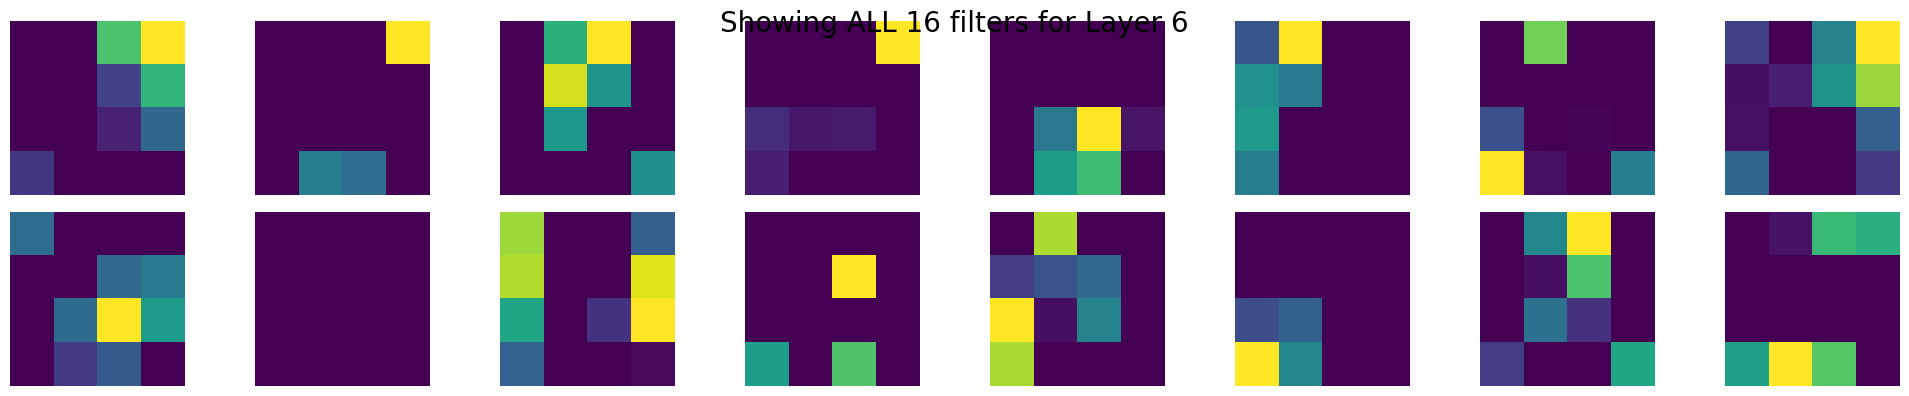

In [43]:
import math

def plot_all_filters(layer_idx):
    f_map = feature_maps[layer_idx]
    num_filters = f_map.shape[-1]

    # Grid size calculate karna (e.g., 128 filters ke liye 8 columns x 16 rows)
    cols = 8
    rows = math.ceil(num_filters / cols)

    plt.figure(figsize=(20, 2 * rows))
    plt.suptitle(f"Showing ALL {num_filters} filters for Layer {layer_idx + 1}", fontsize=20)

    for i in range(num_filters):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(f_map[0, :, :, i], cmap='viridis')
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95) # Title ke liye space
    plt.show()

# Teeno layers ke liye loop (128, 32, 16)
for i in range(len(feature_maps)):
    plot_all_filters(i)